In [252]:
import torch
import torchvision

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from torchmetrics.classification import BinaryAccuracy

from helper_function import plot_decision_boundary

/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [223]:
breastDataset = fetch_openml("breast-w", as_frame = True).frame

In [224]:
X, y = fetch_openml("breast-w", return_X_y = True)

In [225]:
X = X.fillna(X.mean(), axis = 0)

<Axes: >

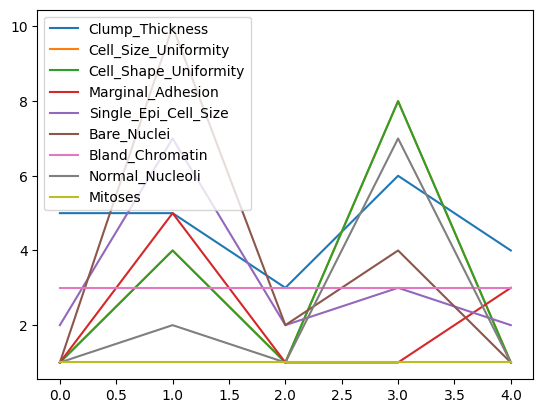

In [226]:
breastDataset.head().plot()

In [227]:
pca = PCA(n_components = 2)
X = pca.fit_transform(X)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


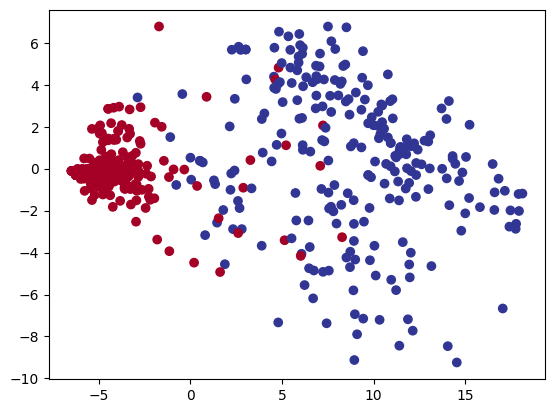

In [228]:
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.RdYlBu)

In [229]:
X_tensor, y_tensor = torch.tensor(X, dtype = torch.float32), torch.tensor(y, dtype = torch.float32)

In [230]:
X_tensor[:5]

tensor([[-4.4428, -0.1060],
        [ 4.8222,  4.8141],
        [-4.6023,  0.5771],
        [ 5.1477, -3.4122],
        [-4.0777,  0.0437]])

In [231]:
y_tensor[:5]

tensor([0., 0., 0., 0., 0.])

In [232]:
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size = 0.2, shuffle = True, random_state = 42)

In [233]:
len(X_train), len(y_train), len(X_test), len(y_test)

(559, 559, 140, 140)

In [234]:
y_train.unique()

tensor([0., 1.])

In [235]:
device = "mps" if torch.mps.is_available() else "cpu"

In [255]:
class BreastCancerModel(torch.nn.Module):
    def __init__(self, in_features = 2, out_features = 1, hidden_units = 32):
        super(BreastCancerModel, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_units = hidden_units

        self.layer = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [256]:
model = BreastCancerModel().to(device)

In [257]:
model

BreastCancerModel(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [258]:
with torch.inference_mode():
    y_logits = model(X_test.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

y_pred[:5], y_test[:5]

(tensor([1., 1., 1., 0., 1.], device='mps:0'), tensor([0., 0., 0., 1., 0.]))

In [259]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
accuracy = BinaryAccuracy().to(device)

In [260]:
epochs = 1000

total_epochs, losses, test_losses = [], [], []

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    train_acc = accuracy(y_pred, y_train.to(device))

    loss = criterion(y_logits, y_train.to(device))
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test.to(device)).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))

        test_acc = accuracy(y_test_pred, y_test.to(device))

        test_loss = criterion(y_test_logits, y_test.to(device))
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.2 * epochs) == 0:
        print(f"Train Losses: {loss:.5f}, Train Accuracy: {train_acc:.2f}")
        print(f"Test Losses: {test_loss:.5f}, Test Accuracy: {test_acc:.2f} \n")


Train Losses: 0.86227, Train Accuracy: 0.21
Test Losses: 0.81638, Test Accuracy: 0.32 

Train Losses: 0.07944, Train Accuracy: 0.97
Test Losses: 0.08540, Test Accuracy: 0.96 

Train Losses: 0.07285, Train Accuracy: 0.97
Test Losses: 0.09487, Test Accuracy: 0.96 

Train Losses: 0.06927, Train Accuracy: 0.97
Test Losses: 0.09716, Test Accuracy: 0.96 

Train Losses: 0.06471, Train Accuracy: 0.97
Test Losses: 0.10179, Test Accuracy: 0.96 



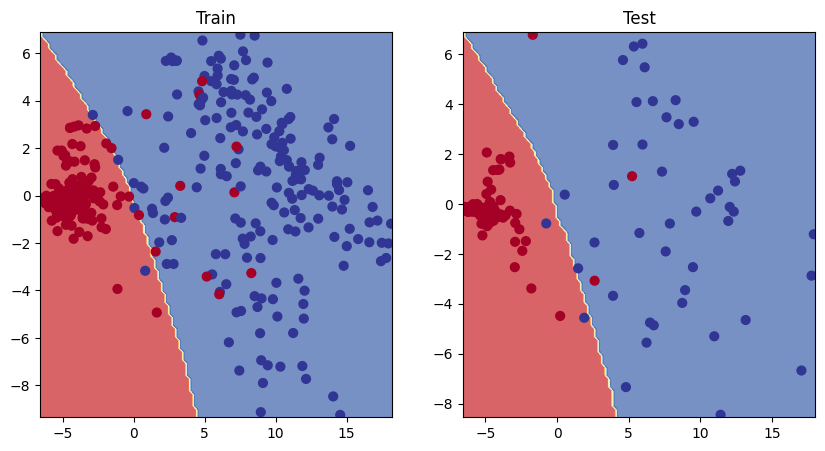

In [262]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [261]:
with torch.inference_mode():
    y_logits = model(X_test.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

y_pred[:5], y_test[:5]

(tensor([0., 0., 0., 1., 0.], device='mps:0'), tensor([0., 0., 0., 1., 0.]))

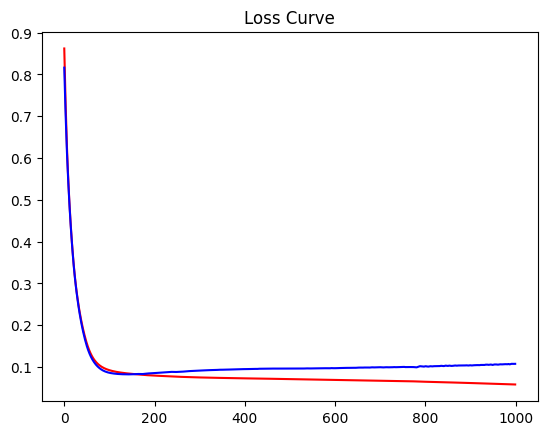

In [263]:
plt.plot(total_epochs, losses, label = "Training Loss", c="red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c="blue")
plt.title("Loss Curve")
plt.show()